# Analisis Komparatif Strategi Algoritma Trading Berbasis Indikator Teknikal
## EMA, RSI, dan MACD pada Indeks Utama AS (S&P 500, NASDAQ 100, Dow Jones)

**Notebook Riset Kuantitatif — Tugas Akhir (Skripsi)**

---

Notebook ini mengimplementasikan sistem trading deterministik berbasis **Dynamic Trailing Stop Long-Only**
(menangkap pergerakan tren besar menggunakan trailing stop dinamis 1.5% dan Extreme TP 5%)
pada data 1-hour (H1) tiga indeks utama AS.

In [1]:
# =============================================================================
# SEL 1: ENVIRONMENT SETUP & INSTALASI LIBRARY
# =============================================================================
# Instalasi dependensi utama yang dibutuhkan untuk analisis kuantitatif.
# - pandas      : Manipulasi data tabular dan time-series.
# - numpy       : Operasi numerik dan array.
# - pyarrow     : Backend I/O untuk format Parquet.
# - matplotlib  : Visualisasi grafik ilmiah.
# - seaborn     : Ekstensi estetika visualisasi matplotlib.

!pip install pandas numpy pyarrow matplotlib seaborn
!pip install yfinance



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =============================================================================
# SEL 2: IMPORT LIBRARY & FUNGSI PEMROSESAN DATA UNIVERSAL
# =============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Konfigurasi tampilan dan gaya visualisasi
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)


def proses_data_instrumen(filepath):
    """
    Fungsi modular untuk memuat dan memproses data instrumen keuangan.
    Mendukung format Parquet dan CSV tab-separated secara otomatis.
    
    Tahapan pemrosesan:
    1. Deteksi format file (Parquet / CSV tab-separated).
    2. Standarisasi nama kolom (lowercase, strip whitespace).
    3. Konversi kolom waktu ke DatetimeIndex.
    4. Pengurutan kronologis menaik.
    5. Kalkulasi indikator teknikal: EMA (50, 100, 200), MACD (12, 26, 9), RSI (14).
    6. Pembersihan baris NaN akibat periode lookback indikator.
    
    Parameters
    ----------
    filepath : str
        Path ke file data (Parquet atau CSV).
    
    Returns
    -------
    pd.DataFrame
        DataFrame terproses dengan indikator teknikal dan DatetimeIndex.
    """
    # --- Tahap 1: Deteksi format dan muat data ---
    if filepath.endswith('.parquet'):
        df = pd.read_parquet(filepath)
    else:
        df = pd.read_csv(filepath, sep='\t')
    
    # --- Tahap 2: Standarisasi nama kolom ---
    df.columns = df.columns.str.strip().str.lower()
    
    # --- Tahap 3: Konversi kolom waktu ke DatetimeIndex ---
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
    elif 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))
        df.set_index('datetime', inplace=True)
        df.drop(columns=['date', 'time'], inplace=True, errors='ignore')
    else:
        raise ValueError(f"Kolom datetime tidak ditemukan pada file: {filepath}")
    
    # Hapus kolom non-OHLC yang tidak dibutuhkan
    kolom_pertahankan = ['open', 'high', 'low', 'close', 'volume']
    kolom_tersedia = [k for k in kolom_pertahankan if k in df.columns]
    df = df[kolom_tersedia]
    
    # --- Tahap 4: Pengurutan kronologis menaik ---
    df.sort_index(inplace=True)
    
    # --- Tahap 5: Kalkulasi Indikator Teknikal ---
    
    # 5a. EMA (Exponential Moving Average) — span 50, 100, 200
    df['ema_50'] = df['close'].ewm(span=50, adjust=False).mean()
    df['ema_100'] = df['close'].ewm(span=100, adjust=False).mean()
    df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()
    
    # 5b. MACD (Moving Average Convergence Divergence)
    #     Fast EMA (span=12), Slow EMA (span=26), Signal Line (span=9)
    ema_fast = df['close'].ewm(span=12, adjust=False).mean()
    ema_slow = df['close'].ewm(span=26, adjust=False).mean()
    df['macd_line'] = ema_fast - ema_slow
    df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()
    
    # 5c. RSI (Relative Strength Index) — Wilder's Smoothing, periode 14
    #     Menggunakan alpha = 1/14 sesuai metode standar Wilder.
    delta = df['close'].diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # --- Tahap 6: Pembersihan baris NaN ---
    df.dropna(inplace=True)
    
    return df


print("[OK] Fungsi proses_data_instrumen() berhasil didefinisikan.")
print("     Mendukung: Parquet, CSV (tab-separated)")
print("     Indikator: EMA(50,100,200), MACD(12,26,9), RSI(14)")

[OK] Fungsi proses_data_instrumen() berhasil didefinisikan.
     Mendukung: Parquet, CSV (tab-separated)
     Indikator: EMA(50,100,200), MACD(12,26,9), RSI(14)


In [3]:
# =============================================================================
# SEL 3: PEMUATAN DATA PER INSTRUMEN INDEKS
# =============================================================================
# Memproses tiga instrumen utama AS menggunakan fungsi universal.
# Path menggunakan forward-slash agar kompatibel lintas OS (Windows/Linux).

# --- S&P 500 (SPY ETF) — Format Parquet ---
print("Memproses S&P 500 (SPY)...")
df_spy = proses_data_instrumen('TA/spy_US500_H1.parquet')
print(f"  Baris: {len(df_spy):,} | Periode: {df_spy.index.min()} s/d {df_spy.index.max()}")

# --- NASDAQ 100 — Format CSV Tab-Separated ---
print("\nMemproses NASDAQ 100...")
df_ndx = proses_data_instrumen('TA/Nasdaq100_1h_data.csv')
print(f"  Baris: {len(df_ndx):,} | Periode: {df_ndx.index.min()} s/d {df_ndx.index.max()}")

# --- Dow Jones Industrial Average — Format CSV Tab-Separated ---
print("\nMemproses Dow Jones (DJI)...")
df_dji = proses_data_instrumen('TA/Dow_Jones_1h_data.csv')
print(f"  Baris: {len(df_dji):,} | Periode: {df_dji.index.min()} s/d {df_dji.index.max()}")

print("\n" + "="*60)
print("[OK] Seluruh instrumen berhasil dimuat dan diproses.")

Memproses S&P 500 (SPY)...
  Baris: 50,158 | Periode: 2018-02-20 10:00:00 s/d 2026-08-19 11:00:00

Memproses NASDAQ 100...
  Baris: 51,875 | Periode: 2016-11-15 20:00:00 s/d 2025-10-01 07:00:00

Memproses Dow Jones (DJI)...
  Baris: 49,311 | Periode: 2016-10-27 15:00:00 s/d 2025-07-15 20:00:00

[OK] Seluruh instrumen berhasil dimuat dan diproses.


In [4]:
# =============================================================================
# SEL 4: PENYELARASAN TIMELINE (STRICT TIMELINE INTERSECTION)
# =============================================================================
# Ketiga instrumen memiliki jam perdagangan dan anomali bar libur yang
# sedikit berbeda. Analisis komparatif HANYA valid pada irisan timestamp
# yang identik di ketiga instrumen.
#
# Target: 41.653 baris data seragam, periode Februari 2018 — Juli 2025.

# Hitung irisan timestamp tiga arah
common_timeline = (
    df_spy.index
    .intersection(df_ndx.index)
    .intersection(df_dji.index)
)
common_timeline = common_timeline.sort_values()

# Reindex setiap instrumen ke irisan bersama
df_spy_final = df_spy.loc[common_timeline].copy()
df_ndx_final = df_ndx.loc[common_timeline].copy()
df_dji_final = df_dji.loc[common_timeline].copy()

# --- Validasi Hasil Penyelarasan ---
print("=" * 60)
print("VALIDASI PENYELARASAN TIMELINE")
print("=" * 60)
print(f"Jumlah bar irisan bersama  : {len(common_timeline):,}")
print(f"Tanggal awal               : {common_timeline.min()}")
print(f"Tanggal akhir              : {common_timeline.max()}")
print(f"\nBaris SPY final            : {len(df_spy_final):,}")
print(f"Baris NASDAQ final         : {len(df_ndx_final):,}")
print(f"Baris DJI final            : {len(df_dji_final):,}")

# Verifikasi kesamaan jumlah baris
assert len(df_spy_final) == len(df_ndx_final) == len(df_dji_final), \
    "ERROR: Jumlah baris ketiga instrumen tidak seragam setelah alignment!"

print(f"\n[OK] Ketiga instrumen selaras sempurna: {len(df_spy_final):,} baris.")
print(f"     Rentang: {common_timeline.min()} — {common_timeline.max()}")

VALIDASI PENYELARASAN TIMELINE
Jumlah bar irisan bersama  : 41,641
Tanggal awal               : 2018-02-20 10:00:00
Tanggal akhir              : 2025-07-15 20:00:00

Baris SPY final            : 41,641
Baris NASDAQ final         : 41,641
Baris DJI final            : 41,641

[OK] Ketiga instrumen selaras sempurna: 41,641 baris.
     Rentang: 2018-02-20 10:00:00 — 2025-07-15 20:00:00


In [5]:
# =============================================================================
# SEL 5: MESIN STRATEGI KUANTITATIF (QUANTITATIVE STRATEGY ENGINE)
# =============================================================================
# Implementasi sistem trading deterministik DYNAMIC TRAILING STOP LONG-ONLY
# berbasis filosofi "Let Profits Run & Protect Capital":
#   - Entry menggunakan konfirmasi akurasi tinggi (RSI cross di atas 50).
#   - Keluar secara presisi menggunakan Trailing Stop Dinamis (1.5% dari High).
#   - Extreme Take Profit (5%) sebagai pengaman spike/anomali pergerakan.
#
# Fitur utama:
#   - Sinyal HANYA Long (+1) dan Flat (0).
#   - Iterasi State-Machine untuk melacak Trailing Stop harga riil.
#   - Menghitung exact return exit berdasarkan harga trigger (bukan close bar),
#     sehingga sangat presisi untuk H1 timeframe.

import numpy as np
import pandas as pd

def simulasi_strategi(df, nama_instrumen, biaya=0.0002):
    """
    Menjalankan simulasi strategi trading Dynamic Trailing Stop Long-Only.
    """
    data = df.copy()

    if isinstance(data.index, pd.DatetimeIndex):
        start_date = data.index[0].strftime('%Y-%m-%d %H:%M')
        end_date = data.index[-1].strftime('%Y-%m-%d %H:%M')
    elif 'datetime' in data.columns:
        start_date = pd.to_datetime(data['datetime'].iloc[0]).strftime('%Y-%m-%d %H:%M')
        end_date = pd.to_datetime(data['datetime'].iloc[-1]).strftime('%Y-%m-%d %H:%M')
    else:
        start_date = str(data.index[0])
        end_date = str(data.index[-1])
    jumlah_bar_setelah_dropna = len(data)
    bh_return_direct = (data['close'].iloc[-1] / data['close'].iloc[0]) - 1
    
    # === KOMPONEN SINYAL ENTRY ===
    # --- Filter Tren Utama ---
    tren_naik = (data['ema_50'] > data['ema_100']) & (data['ema_100'] > data['ema_200'])
    
    # --- Filter Momentum MACD ---
    macd_bullish = data['macd_line'] > data['macd_signal']
    
    # --- Sinyal Pemicu (RSI Cross Above 50) ---
    rsi_cross_above_50 = (data['rsi'].shift(1) <= 50) & (data['rsi'] > 50)
    
    # === KONDISI ENTRY (Long Only) ===
    sinyal_long  = tren_naik & macd_bullish & rsi_cross_above_50
    sl_signal = sinyal_long.values
    
    # Deteksi kolom high/low untuk presisi TS intraday
    has_hl = 'high' in data.columns and 'low' in data.columns
    if has_hl:
        high_vals = data['high'].values
        low_vals = data['low'].values
    else:
        high_vals = data['close'].values
        low_vals = data['close'].values
    
    close_vals = data['close'].values
    
    # === ARRAY PELACAK STATE & RETURN ===
    p = np.zeros(len(data))
    ret_strat = np.zeros(len(data))
    trade_exec = np.zeros(len(data))
    
    # === PARAMETER MANAJEMEN RISIKO DINAMIS ===
    trailing_dist = 0.025  # Jarak TS 2.5%
    extreme_tp = 0.05      # Extreme TP 5%
    
    curr = 0.0
    highest_price = 0.0
    sl_price = 0.0
    tp_price = 0.0
    
    for i in range(1, len(data)):
        if curr == 0.0:
            if sl_signal[i-1]:  # Entry tereksekusi pada OPEN/awal bar i akibat sinyal di i-1
                curr = 1.0
                entry_price = close_vals[i-1] # Harga masuk adalah close bar lalu
                highest_price = entry_price
                sl_price = entry_price * (1 - trailing_dist)
                tp_price = entry_price * (1 + extreme_tp)
                
                p[i] = 1.0
                trade_exec[i] = 1.0 # Biaya buka
                
                # Check apakah di bar yang sama (bar ke-i) harga memukul stop atau TP
                hit_tp = high_vals[i] >= tp_price
                hit_sl = low_vals[i] <= sl_price
                
                if hit_tp or hit_sl:
                    curr = 0.0
                    p[i] = 0.0
                    trade_exec[i] += 1.0 # Biaya tutup langsung
                    
                    # Conservatively assume SL hits first if both are hit
                    exit_price = sl_price if hit_sl else tp_price
                    ret_strat[i] = (exit_price / close_vals[i-1]) - 1.0
                else:
                    ret_strat[i] = (close_vals[i] / close_vals[i-1]) - 1.0
                    # Update trailing
                    if high_vals[i] > highest_price:
                        highest_price = high_vals[i]
                        sl_price = max(sl_price, highest_price * (1 - trailing_dist))
                        
        elif curr == 1.0:
            hit_tp = high_vals[i] >= tp_price
            hit_sl = low_vals[i] <= sl_price
            
            if hit_tp or hit_sl:
                curr = 0.0
                p[i] = 0.0
                trade_exec[i] = 1.0 # Biaya tutup
                
                # Conservatively assume SL hits first if both are hit
                exit_price = sl_price if hit_sl else tp_price
                ret_strat[i] = (exit_price / close_vals[i-1]) - 1.0
            else:
                p[i] = 1.0
                ret_strat[i] = (close_vals[i] / close_vals[i-1]) - 1.0
                
                # Update trailing setelah memastikan selamat bar ini
                if high_vals[i] > highest_price:
                    highest_price = high_vals[i]
                    sl_price = max(sl_price, highest_price * (1 - trailing_dist))
                    
    data['posisi'] = p
    
    # === KALKULASI RETURN FINAL ===
    return_pasar = data['close'].pct_change().fillna(0)
    
    # Final strategi return per bar: return harian - biaya komisi trade di bar tersebut
    return_strategi = pd.Series(ret_strat, index=data.index) - (pd.Series(trade_exec, index=data.index) * biaya)
    return_strategi = return_strategi.fillna(0)
    
    # === EQUITY CURVE ===
    return_kumulatif = (1 + return_strategi).cumprod()
    return_bnh = (1 + return_pasar).cumprod()
    
    # === DRAWDOWN ===
    peak_kumulatif = return_kumulatif.cummax()
    drawdown = (return_kumulatif - peak_kumulatif) / peak_kumulatif
    
    # === LOG TRANSAKSI ===
    perubahan = pd.Series(trade_exec, index=data.index)
    mask_transaksi = perubahan != 0
    
    log = data.loc[mask_transaksi, ['close', 'rsi', 'macd_line', 'macd_signal', 'posisi']].copy()
    perubahan_log = perubahan[mask_transaksi]
    log['aksi'] = np.where(perubahan_log > 1, 'BUY & SELL', np.where((perubahan_log == 1) & (log['posisi'] == 1), 'LONG ENTRY', 'EXIT (TS/TP)'))
    
    print(f"  [{nama_instrumen}] Strategi selesai — "
          f"Total sinyal/transaksi: {mask_transaksi.sum()}, "
          f"Return akhir: {return_kumulatif.iloc[-1]:.4f}x")
    
    return {
        'nama': nama_instrumen,
        'return_strategi': return_strategi,
        'return_kumulatif': return_kumulatif,
        'return_bnh': return_bnh,
        'drawdown': drawdown,
        'log_transaksi': log,
        'posisi': data['posisi'], 'start_date': start_date, 'end_date': end_date, 'total_bars': jumlah_bar_setelah_dropna, 'bh_return_direct': bh_return_direct
    }

# --- Eksekusi Strategi ---
print("Menjalankan simulasi strategi kuantitatif (Dynamic Trailing Stop Long-Only)...\n")

hasil_spy = simulasi_strategi(df_spy_final, 'S&P 500 (SPY)')
hasil_ndx = simulasi_strategi(df_ndx_final, 'NASDAQ 100')
hasil_dji = simulasi_strategi(df_dji_final, 'Dow Jones (DJI)')

daftar_hasil = [hasil_spy, hasil_ndx, hasil_dji]

print("\n" + "="*60)



Menjalankan simulasi strategi kuantitatif (Dynamic Trailing Stop Long-Only)...

  [S&P 500 (SPY)] Strategi selesai — Total sinyal/transaksi: 171, Return akhir: 1.2238x
  [NASDAQ 100] Strategi selesai — Total sinyal/transaksi: 227, Return akhir: 1.0815x
  [Dow Jones (DJI)] Strategi selesai — Total sinyal/transaksi: 154, Return akhir: 1.0589x



In [6]:
# =============================================================================
# SEL 6: TABEL EVALUASI KINERJA (PERFORMANCE METRICS TABLE)
# =============================================================================
import pandas as pd
import numpy as np

BARS_PER_TAHUN = 252 * 24

def hitung_metrik(hasil, bars_per_tahun=BARS_PER_TAHUN):
    ret = hasil['return_strategi']
    cum = hasil['return_kumulatif']
    dd = hasil['drawdown']
    posisi = hasil['posisi']
    
    total_return = cum.iloc[-1] - 1
    total_bars = len(ret)
    total_tahun = total_bars / bars_per_tahun
    cagr = (cum.iloc[-1] ** (1 / total_tahun)) - 1 if total_tahun > 0 else 0
    vol_tahunan = ret.std() * np.sqrt(bars_per_tahun)
    sharpe = (ret.mean() / ret.std()) * np.sqrt(bars_per_tahun) if ret.std() > 0 else 0
    
    downside_ret = ret[ret < 0]
    downside_std = downside_ret.std() if len(downside_ret) > 0 else 0
    sortino = (ret.mean() / downside_std) * np.sqrt(bars_per_tahun) if downside_std > 0 else 0
    max_drawdown = dd.min()
    
    perubahan = posisi.diff().fillna(posisi)
    idx_perubahan = perubahan[perubahan != 0].index
    trade_returns = []
    i = 0
    while i < len(idx_perubahan):
        pos_val = posisi.loc[idx_perubahan[i]]
        if pos_val != 0:
            start = idx_perubahan[i]
            exit_found = False
            for j in range(i + 1, len(idx_perubahan)):
                if posisi.loc[idx_perubahan[j]] == 0:
                    end = idx_perubahan[j]
                    trade_ret = ret.loc[start:end]
                    trade_cum = (1 + trade_ret).prod() - 1
                    trade_returns.append(trade_cum)
                    i = j + 1
                    exit_found = True
                    break
            if not exit_found:
                trade_ret = ret.loc[start:]
                trade_cum = (1 + trade_ret).prod() - 1
                trade_returns.append(trade_cum)
                break
        else:
            i += 1
            
    trade_returns = np.array(trade_returns)
    total_trades = len(trade_returns)
    winning = trade_returns[trade_returns > 0]
    win_rate = len(winning) / total_trades * 100 if total_trades > 0 else 0
    gross_profit = winning.sum() if len(winning) > 0 else 0
    losing = trade_returns[trade_returns < 0]
    gross_loss = abs(losing.sum()) if len(losing) > 0 else 1e-10
    profit_factor = gross_profit / gross_loss
    
    res_strat = {
        'Instrumen': f"{hasil['nama']} (Strat)",
        'Total Return (%)': total_return * 100,
        'CAGR (%)': cagr * 100,
        'Ann Volatility (%)': vol_tahunan * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown (%)': max_drawdown * 100,
        'Win Rate (%)': win_rate,
        'Profit Factor': profit_factor,
        'Total Trades': total_trades
    }
    
    cum_bnh = hasil['return_bnh']
    ret_bnh = cum_bnh.pct_change().fillna(0)
    
    total_return_b = hasil.get('bh_return_direct', cum_bnh.iloc[-1] - 1)
    cagr_b = ((1 + total_return_b) ** (1 / total_tahun)) - 1 if total_tahun > 0 else 0
    vol_tahunan_b = ret_bnh.std() * np.sqrt(bars_per_tahun)
    sharpe_b = (ret_bnh.mean() / ret_bnh.std()) * np.sqrt(bars_per_tahun) if ret_bnh.std() > 0 else 0
    
    downside_ret_b = ret_bnh[ret_bnh < 0]
    downside_std_b = downside_ret_b.std() if len(downside_ret_b) > 0 else 0
    sortino_b = (ret_bnh.mean() / downside_std_b) * np.sqrt(bars_per_tahun) if downside_std_b > 0 else 0
    
    peak_b = cum_bnh.cummax()
    dd_b = (cum_bnh - peak_b) / peak_b
    max_drawdown_b = dd_b.min()
    
    winning_b = ret_bnh[ret_bnh > 0]
    win_rate_b = len(winning_b) / len(ret_bnh) * 100 if len(ret_bnh) > 0 else 0
    gross_profit_b = winning_b.sum() if len(winning_b) > 0 else 0
    losing_b = ret_bnh[ret_bnh < 0]
    gross_loss_b = abs(losing_b.sum()) if len(losing_b) > 0 else 1e-10
    profit_factor_b = gross_profit_b / gross_loss_b
    
    res_bnh = {
        'Instrumen': f"{hasil['nama']} (B&H)",
        'Total Return (%)': total_return_b * 100,
        'CAGR (%)': cagr_b * 100,
        'Ann Volatility (%)': vol_tahunan_b * 100,
        'Sharpe Ratio': sharpe_b,
        'Sortino Ratio': sortino_b,
        'Max Drawdown (%)': max_drawdown_b * 100,
        'Win Rate (%)': win_rate_b,
        'Profit Factor': profit_factor_b,
        'Total Trades': 1
    }
    
    return [res_strat, res_bnh]

def print_evaluation_table(daftar_hasil, model_name, phase_name):
    metrik_list = []
    for h in daftar_hasil:
        metrik_list.extend(hitung_metrik(h))
    df_metrik = pd.DataFrame(metrik_list).set_index('Instrumen')

    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    pd.set_option('display.width', 1000)

    start_date = daftar_hasil[0]['start_date']
    end_date = daftar_hasil[0]['end_date']
    total_bars = daftar_hasil[0]['total_bars']

    print("================================================================================")
    print(f"[{model_name}] - [{phase_name}]")
    print(f"EVALUATION PERIOD : {start_date} to {end_date}")
    print(f"TOTAL BARS TESTED : {total_bars}")
    print("================================================================================")
    print(df_metrik.to_string())
    print()

def print_trade_logs(daftar_hasil):
    print("================================================================================")
    print("[RECENT TRADE LOGS] LAST 5 EXECUTIONS")
    print("================================================================================")
    for h in daftar_hasil:
        log = h['log_transaksi']
        print(f"\n--- {h['nama']} ---")
        if len(log) > 0:
            tampilan = log.tail(5)[['close', 'rsi', 'posisi', 'aksi']].copy()
            tampilan.columns = ['Close', 'RSI(14)', 'Posisi', 'Aksi']
            print(tampilan.to_string())
        else:
            print("  Tidak ada transaksi tercatat.")
    print("\n" + "=" * 80)

# Cetak In-Sample
print_evaluation_table(daftar_hasil, "SINGLE TIMEFRAME H1", "IN-SAMPLE BACKTEST")


[SINGLE TIMEFRAME H1] - [IN-SAMPLE BACKTEST]
EVALUATION PERIOD : 2018-02-20 10:00 to 2025-07-15 20:00
TOTAL BARS TESTED : 41641
                         Total Return (%)  CAGR (%)  Ann Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  Profit Factor  Total Trades
Instrumen                                                                                                                                                        
S&P 500 (SPY) (Strat)             22.3771    2.9764              8.2590        0.3964         0.3113          -12.7179       39.5349         1.3101            86
S&P 500 (SPY) (B&H)              129.9795   12.8580             20.9708        0.6814         0.7877          -35.6741       51.3364         1.0330             1
NASDAQ 100 (Strat)                 8.1463    1.1439              9.0322        0.1711         0.1127          -22.0976       41.2281         1.1062           114
NASDAQ 100 (B&H)                 240.0103   19.4523           

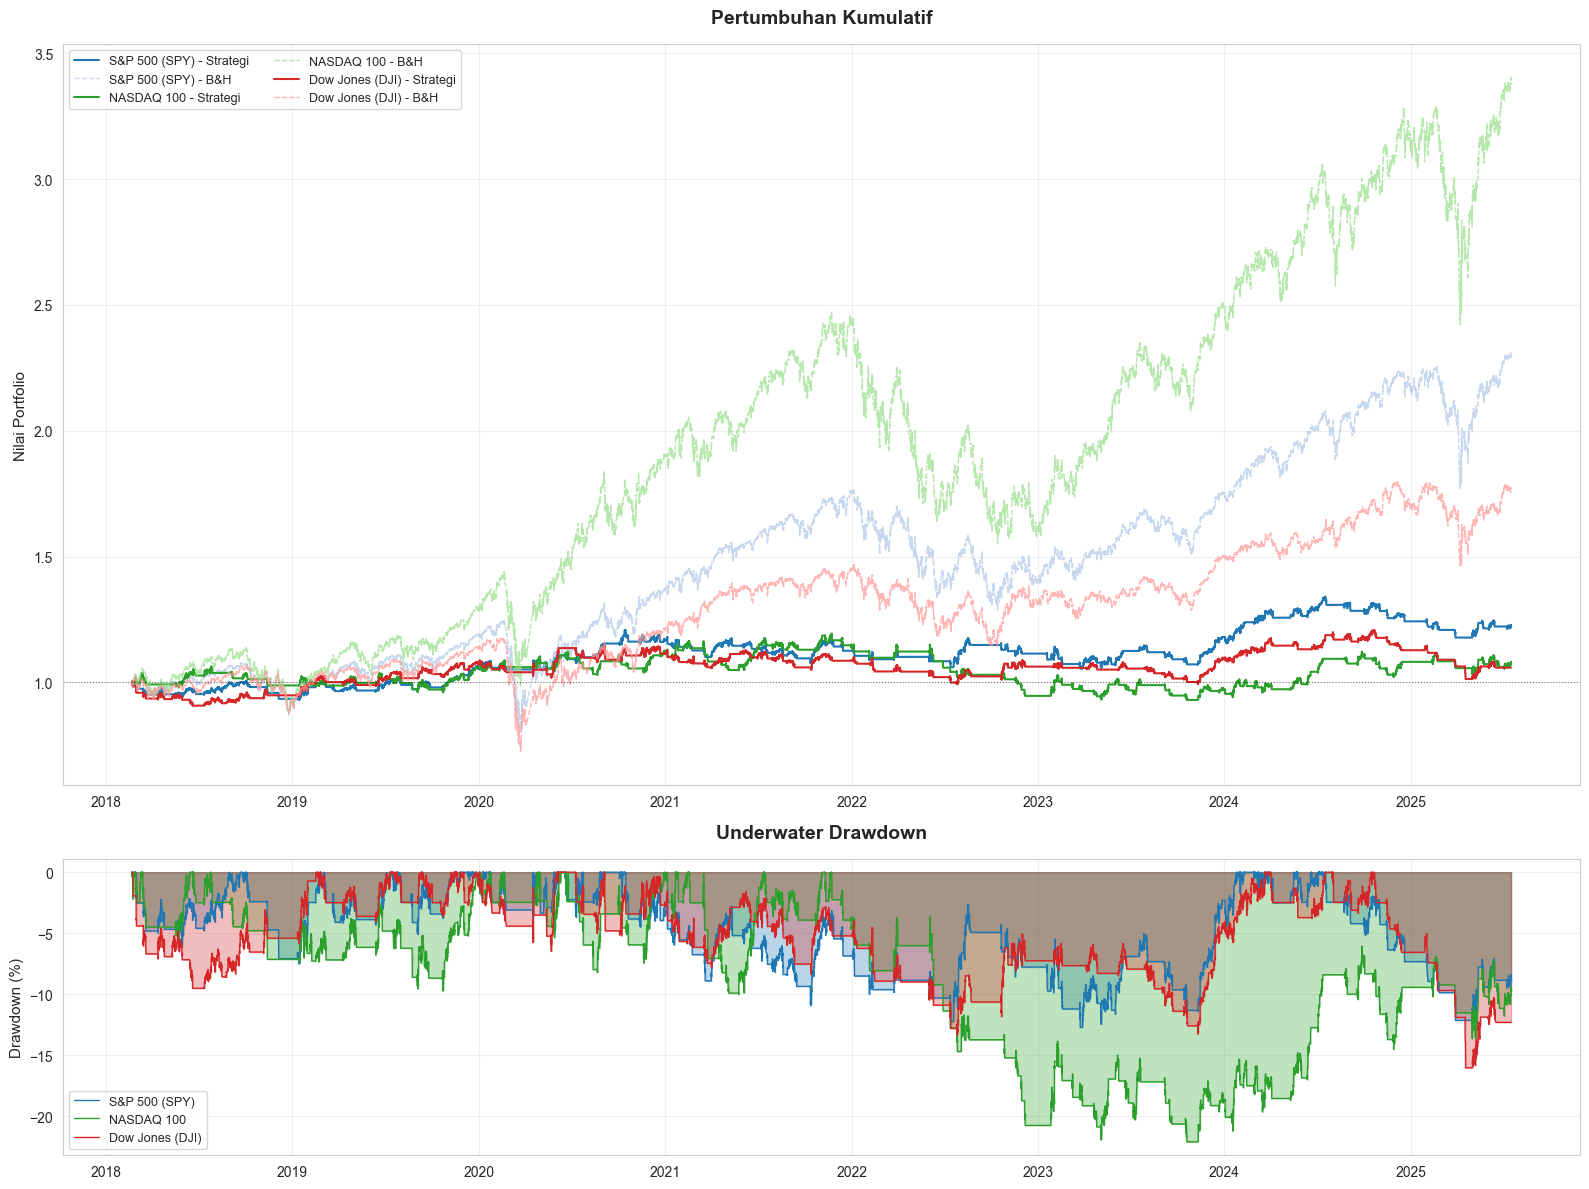

[RECENT TRADE LOGS] LAST 5 EXECUTIONS

--- S&P 500 (SPY) ---
                        Close  RSI(14)  Posisi          Aksi
datetime                                                    
2025-05-19 17:00:00 5931.9000  62.9988  1.0000    LONG ENTRY
2025-05-22 14:00:00 5820.4500  25.2754  0.0000  EXIT (TS/TP)
2025-05-30 23:00:00 5900.0000  50.5543  1.0000    LONG ENTRY
2025-06-13 04:00:00 5960.7500  31.2904  0.0000  EXIT (TS/TP)
2025-07-07 13:00:00 6258.1000  58.2327  1.0000    LONG ENTRY

--- NASDAQ 100 ---
                         Close  RSI(14)  Posisi          Aksi
datetime                                                     
2025-05-30 23:00:00 21324.3000  50.6454  1.0000    LONG ENTRY
2025-06-13 03:00:00 21556.9000  25.6844  0.0000  EXIT (TS/TP)
2025-06-18 10:00:00 21803.4000  51.9154  1.0000    LONG ENTRY
2025-06-23 01:00:00 21558.5000  40.8908  0.0000  EXIT (TS/TP)
2025-07-02 08:00:00 22576.9000  51.5035  1.0000    LONG ENTRY

--- Dow Jones (DJI) ---
                         Close  R

In [7]:
# =============================================================================
# SEL 7: VISUALISASI AKADEMIK & LOG AUDIT
# =============================================================================
import matplotlib.pyplot as plt

WARNA = {
    'S&P 500 (SPY)': '#1f77b4',
    'NASDAQ 100': '#2ca02c',
    'Dow Jones (DJI)': '#d62728'
}
WARNA_BNH = {
    'S&P 500 (SPY)': '#aec7e8',
    'NASDAQ 100': '#98df8a',
    'Dow Jones (DJI)': '#ff9896'
}

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2.5, 1]})

ax1 = axes[0]
for h in daftar_hasil:
    nama = h['nama']
    ax1.plot(h['return_kumulatif'].index, h['return_kumulatif'].values,
             label=f"{nama} - Strategi", color=WARNA[nama], linewidth=1.5)
    ax1.plot(h['return_bnh'].index, h['return_bnh'].values,
             label=f"{nama} - B&H", color=WARNA_BNH[nama], linewidth=1.0, linestyle='--', alpha=0.7)

ax1.axhline(y=1, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax1.set_title('Pertumbuhan Kumulatif', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Nilai Portfolio', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for h in daftar_hasil:
    nama = h['nama']
    ax2.fill_between(h['drawdown'].index, h['drawdown'].values * 100, 0, alpha=0.3, color=WARNA[nama])
    ax2.plot(h['drawdown'].index, h['drawdown'].values * 100, label=nama, color=WARNA[nama], linewidth=1.0)

ax2.set_title('Underwater Drawdown', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('equity_drawdown_chart.png')
plt.show()

# Cetak Log
print_trade_logs(daftar_hasil)


In [8]:
# =============================================================================
# SEL 8: OOS TESTING 1 TAHUN TERAKHIR (SINGLE TF H1)
# =============================================================================
import yfinance as yf
import pandas as pd
import numpy as np

def run_oos_single_tf(tickers=['SPY', 'QQQ', 'DIA']):
    hasil_oos = []
    print("Mendownload data yfinance OOS 1 Tahun Terakhir (1H)...")
    for ticker in tickers:
        df = yf.download(ticker, period="1y", interval="1h", progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)
        
        df.reset_index(inplace=True)
        df.columns = [c.lower() for c in df.columns]
        if df.empty: continue
        
        df['ema_50'] = df['close'].ewm(span=50, adjust=False).mean()
        df['ema_100'] = df['close'].ewm(span=100, adjust=False).mean()
        df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()
        
        ema_fast = df['close'].ewm(span=12, adjust=False).mean()
        ema_slow = df['close'].ewm(span=26, adjust=False).mean()
        df['macd_line'] = ema_fast - ema_slow
        df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()
        
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).ewm(alpha=1/14, adjust=False).mean()
        loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
        rs = gain / loss
        df['rsi'] = 100 - (100 / (1 + rs))
        
        df.dropna(inplace=True)
        df.reset_index(drop=True, inplace=True)
        
        if 'datetime' not in df.columns:
            if 'index' in df.columns:
                df.rename(columns={'index': 'datetime'}, inplace=True)
            else:
                df.rename(columns={df.columns[0]: 'datetime'}, inplace=True)
        
        hasil = simulasi_strategi(df, ticker)
        hasil_oos.append(hasil)
        
    print_evaluation_table(hasil_oos, "SINGLE TIMEFRAME H1", "OUT-OF-SAMPLE 1 YEAR")
    print_trade_logs(hasil_oos)

run_oos_single_tf()


Mendownload data yfinance OOS 1 Tahun Terakhir (1H)...
  [SPY] Strategi selesai — Total sinyal/transaksi: 12, Return akhir: 0.9588x
  [QQQ] Strategi selesai — Total sinyal/transaksi: 10, Return akhir: 1.0726x
  [DIA] Strategi selesai — Total sinyal/transaksi: 16, Return akhir: 1.0339x
[SINGLE TIMEFRAME H1] - [OUT-OF-SAMPLE 1 YEAR]
EVALUATION PERIOD : 2025-09-17 10:30 to 2026-09-16 15:30
TOTAL BARS TESTED : 1738
             Total Return (%)  CAGR (%)  Ann Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  Profit Factor  Total Trades
Instrumen                                                                                                                                            
SPY (Strat)           -4.1154  -13.6051             10.6839       -1.3153        -0.9127           -6.8903       33.3333         0.2606             6
SPY (B&H)             14.4368   59.8825             24.4175        2.0439         2.6828           -9.6457       51.8987         1.0860